In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################

df_kzhn = pd.read_excel("База_соц_эконом_неоднор_регионов.xlsx", sheet_name="КЖН (рейтинг)")
df_kf = pd.read_excel("База_соц_эконом_неоднор_регионов.xlsx", sheet_name="Коэф фондов", skiprows=2)

df_kf = df_kf.iloc[:, [1, 2, 3]]       # берем только Region, Date, KF
df_kf.columns = ["Region", "Date", "KF"]

df_kzhn["Date"] = pd.to_numeric(df_kzhn["Date"], errors="coerce")
df_kzhn["K_PLQ"] = pd.to_numeric(df_kzhn["K_PLQ"], errors="coerce")
df_kzhn = df_kzhn.dropna(subset=["Region", "Date", "K_PLQ"])

df_kf["Region"] = df_kf["Region"].astype(str).str.strip()
df_kf["Date"] = pd.to_numeric(df_kf["Date"], errors="coerce")
df_kf["KF"] = pd.to_numeric(df_kf["KF"], errors="coerce")
df_kf = df_kf.dropna(subset=["Region", "Date", "KF"])

df = df_kzhn.merge(df_kf, on=["Region", "Date"], how="inner")

# Выбираем за какие годы проводим кластеризацию
df_recent = df[df["Date"].isin([2019, 2020, 2021, 2022, 2023, 2024])]
df_year = df_recent.groupby("Region", as_index=False).agg(K_PLQ=("K_PLQ", "mean"), KF=("KF", "mean"))


df_clust = df_year[["Region", "K_PLQ", "KF"]].dropna().copy()

with open('filter_for_cluster.pkl', 'rb') as loaded:
    good_regions_iqr = pickle.load(loaded)

df_clust = df_clust[df_clust['Region'].isin(good_regions_iqr)].copy()



X = df_clust[["K_PLQ", "KF"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [3]:
###############################
    #ПОДБОР ЧИСЛА КЛАСТЕРОВ
###############################
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

k=2: inertia=82.60, silhouette=0.4518
k=3: inertia=61.44, silhouette=0.3773
k=4: inertia=45.45, silhouette=0.3933
k=5: inertia=37.87, silhouette=0.3380
k=6: inertia=30.95, silhouette=0.3148
k=7: inertia=25.27, silhouette=0.3459
k=8: inertia=21.93, silhouette=0.3486
k=9: inertia=18.68, silhouette=0.3797
k=10: inertia=16.58, silhouette=0.3560


In [4]:
###############################
    #ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ
###############################

optimal_k = 3  # можно поменять, исходя из вывода выше
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust["Cluster"] = kmeans.fit_predict(X_scaled) + 1

In [5]:
closest_regions = []

for cl in sorted(df_clust["Cluster"].unique()):
    mask = df_clust["Cluster"] == cl
    points = X_scaled[mask]

    # индекс центроида = номер кластера - 1
    center = kmeans.cluster_centers_[cl - 1]

    dists = np.linalg.norm(points - center, axis=1)
    idx_min = dists.argmin()

    row_closest = df_clust[mask].iloc[idx_min]
    closest_regions.append(row_closest)

closest_df = pd.DataFrame(closest_regions)
print(closest_df[["Cluster", "Region", "K_PLQ", "KF"]])


    Cluster              Region      K_PLQ         KF
58        1  Ростовская область  60.641833  13.716667
24        2  Курганская область  35.656833  10.750000
37        3  Пензенская область  51.583167  10.650000


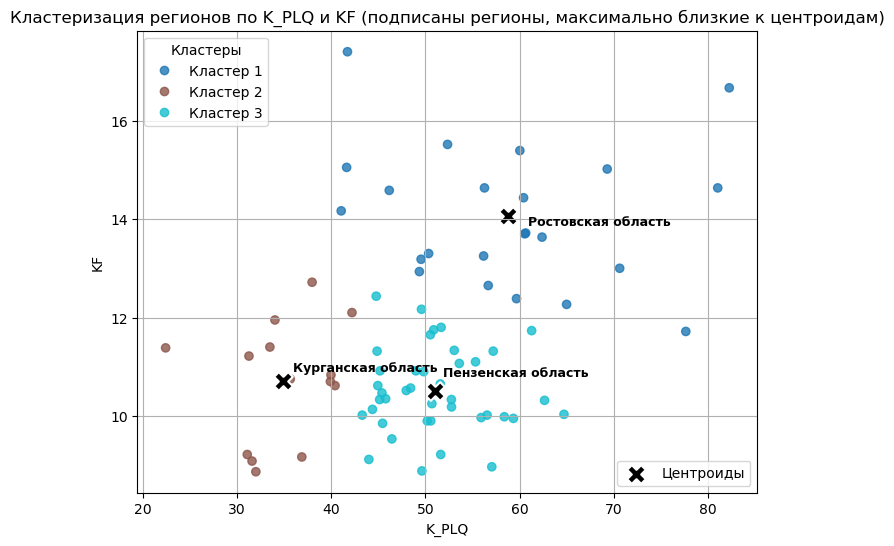

In [6]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_clust["K_PLQ"],
    df_clust["KF"],
    c=df_clust["Cluster"],
    cmap="tab10",
    alpha=0.8
)

# центроиды 
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="black",
    s=180,
    marker="X",
    edgecolor="white",
    linewidth=1.5,
    label="Центроиды"
)

# подписи только ближайших регионов
for _, row in closest_df.iterrows():
    plt.text(
        row["K_PLQ"] + 0.3,
        row["KF"] + 0.15,
        row["Region"],
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("K_PLQ")
plt.ylabel("KF")
plt.title("Кластеризация регионов по K_PLQ и KF (подписаны регионы, максимально близкие к центроидам)")

handles, _ = scatter.legend_elements(prop="colors", num=None)
labels = [f"Кластер {k}" for k in sorted(df_clust["Cluster"].unique())]
cluster_legend = plt.legend(handles, labels, title="Кластеры", loc="upper left")
plt.gca().add_artist(cluster_legend)
plt.legend(loc="lower right")

plt.grid(True)
plt.show()


In [7]:
cluster_summary = df_clust.groupby("Cluster").agg(
    mean_K_PLQ=("K_PLQ", "mean"),
    median_K_PLQ=("K_PLQ", "median"),
    mean_KF=("KF", "mean"),
    median_KF=("KF", "median"),
    count=("Region", "count")
).reset_index()

print(cluster_summary)

   Cluster  mean_K_PLQ  median_K_PLQ    mean_KF  median_KF  count
0        1   58.729659     59.669667  14.053261  13.716667     23
1        2   34.920631     34.841250  10.714286  10.791667     14
2        3   51.057713     50.546333  10.511250  10.341667     40


In [8]:
# просто список регионов по каждому кластеру
clusters_regions = (
    df_clust
    .sort_values(["Cluster", "Region"])
    .groupby("Cluster")["Region"]
    .apply(list)
    .reset_index(name="Regions")
)
for _, row in clusters_regions.iterrows():
    cluster_id = row["Cluster"]
    regions = row["Regions"]  
    print(f"Кластер {cluster_id}:")
    for r in regions:
        print(f"  - {r}")
    print()  

Кластер 1:
  - Амурская область
  - Белгородская область
  - Воронежская область
  - Краснодарский край
  - Красноярский край
  - Липецкая область
  - Магаданская область
  - Московская область
  - Нижегородская область
  - Новосибирская область
  - Пермский край
  - Республика Адыгея
  - Республика Башкортостан
  - Республика Саха (Якутия)
  - Республика Татарстан
  - Ростовская область
  - Сахалинская область
  - Свердловская область
  - Смоленская область
  - Тюменская область
  - Чукотский автономный округ
  - г. Москва
  - г. Санкт-Петербург

Кластер 2:
  - Алтайский край
  - Архангельская область
  - Еврейская автономная область
  - Забайкальский край
  - Кабардино-Балкарская Республика
  - Карачаево-Черкесская Республика
  - Курганская область
  - Республика Алтай
  - Республика Бурятия
  - Республика Ингушетия
  - Республика Калмыкия
  - Республика Карелия
  - Республика Северная Осетия - Алания
  - Республика Тыва

Кластер 3:
  - Астраханская область
  - Брянская область
  - В

In [9]:
region_cluster = df_clust[['Region', 'Cluster']].copy()
region_cluster.head()

,Region,Cluster
0,Алтайский край,2
1,Амурская область,1
2,Архангельская область,2
3,Астраханская область,3
4,Белгородская область,1


In [10]:
#region_cluster.to_excel('region_cluster.xlsx')

In [11]:
cluster_dummies = pd.get_dummies(region_cluster['Cluster'],prefix='Cluster').astype(int)

region_cluster = pd.concat([region_cluster, cluster_dummies], axis=1)

region_cluster = region_cluster.drop(columns=['Cluster', 'Cluster_3'])

region_cluster.head()

,Region,Cluster_1,Cluster_2
0,Алтайский край,0,1
1,Амурская область,1,0
2,Архангельская область,0,1
3,Астраханская область,0,0
4,Белгородская область,1,0


In [12]:
pickle_filename = 'region_cluster_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(region_cluster, f)